### Image Distributions With Intesity Plots
In this demonstration, we will try to interpret image distributions using histograms and intensity plots

What we will cover in this notebook:
- Plotting histogram of image intensity plots
- Analysing image statistics

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

#### Sample Images
We will use same sample images used in the previous exercises.

In [2]:
image1 = cv2.imread('data/bicycle.png')
image2 = cv2.imread('data/dolphin.png')

In [3]:
# Utility function to display images
def show_image(img, fig_size = None):
    print(img.shape)
    img = img.astype('uint8')

    if fig_size is not None:
        plt.figure(figsize=fig_size)

    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.show()

(320, 500, 3)


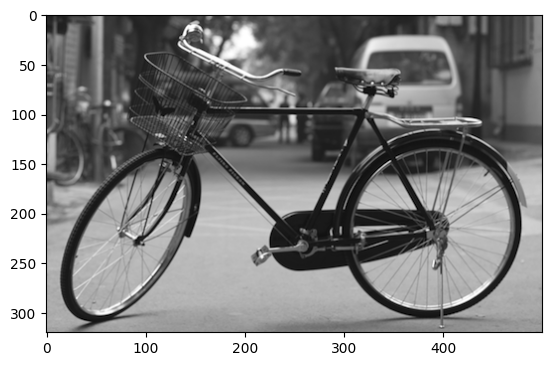

(320, 500, 3)


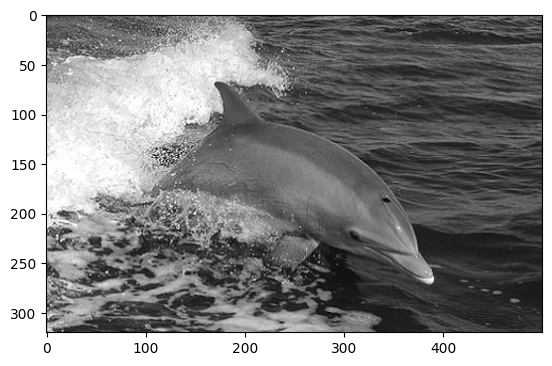

In [4]:
show_image(image1)
show_image(image2)

### Histogram

A histogram represents the distribution of pixel intensity values in an image, helping us understand brightness, contrast and overall image composition.

To analyse intensity distribution, we can flatten (`ravel()`) the image into a 1D array and use `plt.hist()` to compute the histogram.

For grayscale images, this shows the spread of pixel values (0–255).
For RGB images, we can plot separate histograms for the Red, Green and Blue channels.

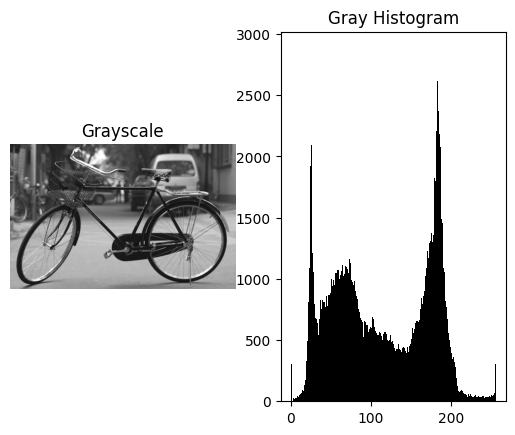

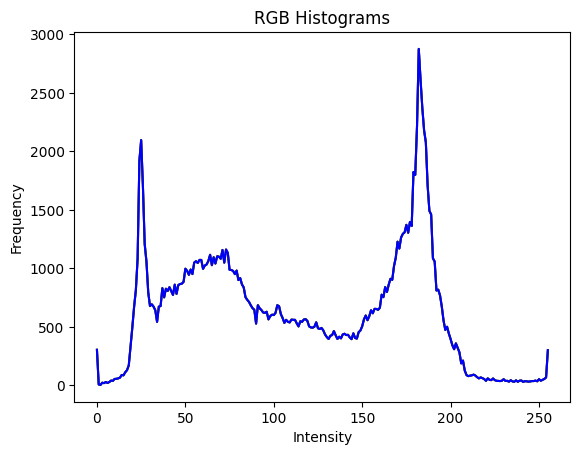

In [5]:
# Grayscale + Histogram
gray_scale = cv2.cvtColor(image1, cv2.COLOR_BGR2GRAY)
plt.subplot(121), plt.imshow(gray_scale, cmap='gray'), plt.axis("off"), plt.title("Grayscale")
plt.subplot(122), plt.hist(gray_scale.ravel(),256, range=[0,256],color='k'), plt.title("Gray Histogram")
plt.show()

# RGB Histograms
for i,c in enumerate(('r','g','b')):
    plt.plot(cv2.calcHist([image1],[i],None,[256],[0,256]), color=c)
plt.title("RGB Histograms"), plt.xlabel("Intensity"), plt.ylabel("Frequency")
plt.show()

OpenCV provides an in-built function `cv2.calcHist()` for histogram calculation. It is more efficient and widely used in image processing tasks.

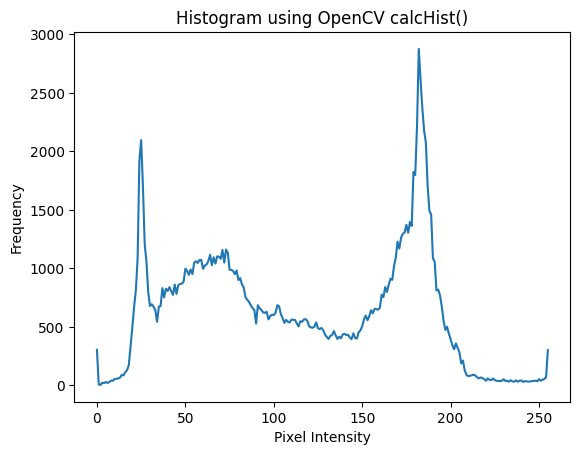

In [6]:
histg = cv2.calcHist([image1], [0], None, [256], [0, 256])

# Plot histogram
plt.plot(histg)
plt.title("Histogram using OpenCV calcHist()")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()

`cv2.imread()` loads the grayscale image, `cv2.calcHist()` computes its histogram and `plt.plot()` displays it with title and labels.

### Image Statistics

Let us analyse image statistics using Python

In [7]:
def image_stats(img):
    max = np.max(img)
    print('Max pixel value:', max)
    min = np.min(img)
    print('Min pixel value:', min)
    mean = np.mean(img)
    print('Mean pixel value:', mean)
    median = np.median(img)
    print('Median pixel value:', median)

In [8]:
image_stats(image1)

Max pixel value: 255
Min pixel value: 0
Mean pixel value: 114.17345625
Median pixel value: 110.0


Histograms and image statistics are important exploratory data analysis (EDA) steps during image processing and analysis. We will learn later how these steps are important in more technical concepts like **transfer learning** and checking **data drifts in images**. We will discuss these concepts much later in this course.

In this notebook, we explored how to analyse image intensity distributions using histogram plots and applying image statistics.